In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import json

data_dir = Path("/home/bjoern/Projects/Masterarbeit/simdata/server/baseline")

filename_pattern = re.compile(
    r"base(\d+)agent(\d+)_(\d+)-(\d+)#(\d+)"
)

rows = []

for file in data_dir.iterdir():

    if file.suffix != ".json":
        continue

    match = filename_pattern.match(file.stem)

    if not match:
        print(f"Skipping {file.name}")
        continue

    experiment, agent, start, goal, run = map(int, match.groups())

    with open(file) as f:
        data = json.load(f)

    info = data["info"]

    row = {
        "experiment": experiment,
        "agent": agent,
        "start": start,
        "goal": goal,
        "run": run,
        "movement": f"{start}-{goal}",
        "converged": data["trajectory"] is not None,
        "NJS": info.get("NJS"),
        "EE_NJS": info.get("Endeffector_NJS"),
    }

    traj = data["trajectory"]

    if traj is not None:

        points = traj["points"]
        joints = traj["joint_names"]

        start_pos = points[0]["positions"]
        end_pos = points[-1]["positions"]

        for joint, s, e in zip(joints, start_pos, end_pos):
            row[f"{joint}_disp"] = e - s

    rows.append(row)


df = pd.DataFrame(rows)
print(df.head())

   experiment  agent  start  goal  run movement  converged           NJS  \
0          13      1      3     6    2      3-6       True  1.698856e+07   
1          10      2      1     3    2      1-3       True  2.080785e+06   
2          34      1      3     7    1      3-7      False           NaN   
3           2      1      3     5    1      3-5       True  5.999101e+06   
4          46      1      3     7    1      3-7      False           NaN   

       EE_NJS  columna_rot_joint_disp  columna_flex_joint_disp  \
0  161.275011                0.233775                 0.219426   
1   47.969835               -0.055978                 0.455981   
2   49.867416                     NaN                      NaN   
3  279.305360                0.160715                 0.223167   
4   90.583766                     NaN                      NaN   

   sternoclavicular_yaw_joint_disp  sternoclavicular_pitch_joint_disp  \
0                         0.049633                          -0.049827   


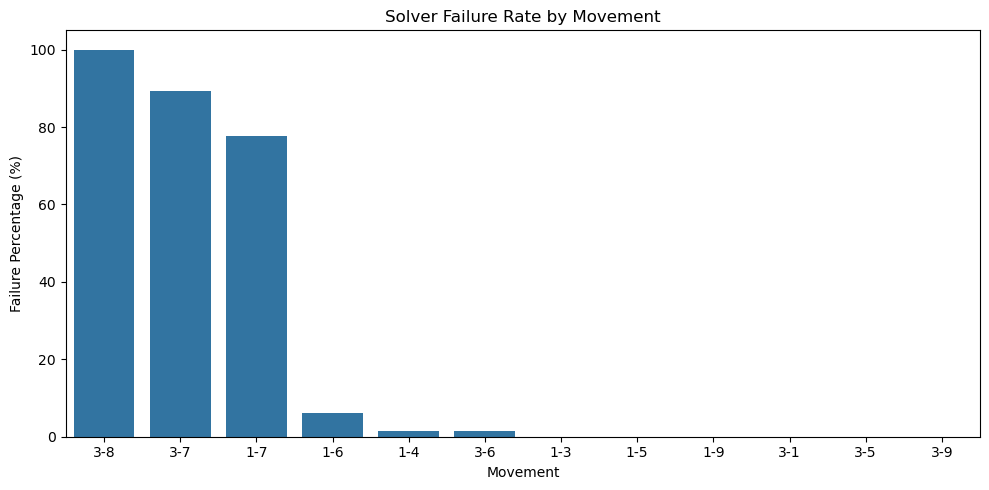

In [23]:
df["failure"] = ~df["converged"]

failure_rates = (
    df.groupby("movement")["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
      .sort_values("failure_percent", ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=failure_rates,
    x="movement",
    y="failure_percent"
)

plt.ylabel("Failure Percentage (%)")
plt.xlabel("Movement")
plt.title("Solver Failure Rate by Movement")

plt.tight_layout()
plt.show()

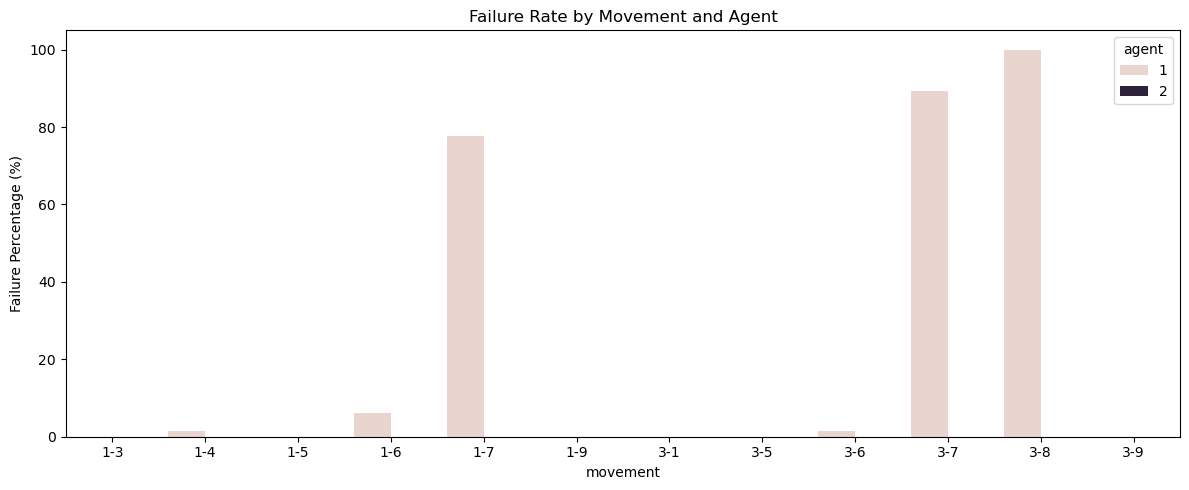

In [24]:
failure_rates = (
    df.groupby(["movement", "agent"])["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=failure_rates,
    x="movement",
    y="failure_percent",
    hue="agent"
)

plt.ylabel("Failure Percentage (%)")
plt.title("Failure Rate by Movement and Agent")

plt.tight_layout()
plt.show()

In [25]:
print(df["agent"].value_counts())
print(df["agent"].value_counts())
print(df.groupby("agent")["movement"].unique())

agent
1    861
2    115
Name: count, dtype: int64
agent
1    861
2    115
Name: count, dtype: int64
agent
1    [3-6, 3-7, 3-5, 3-1, 1-3, 3-8, 1-6, 1-9, 3-9, ...
2                                                [1-3]
Name: movement, dtype: object


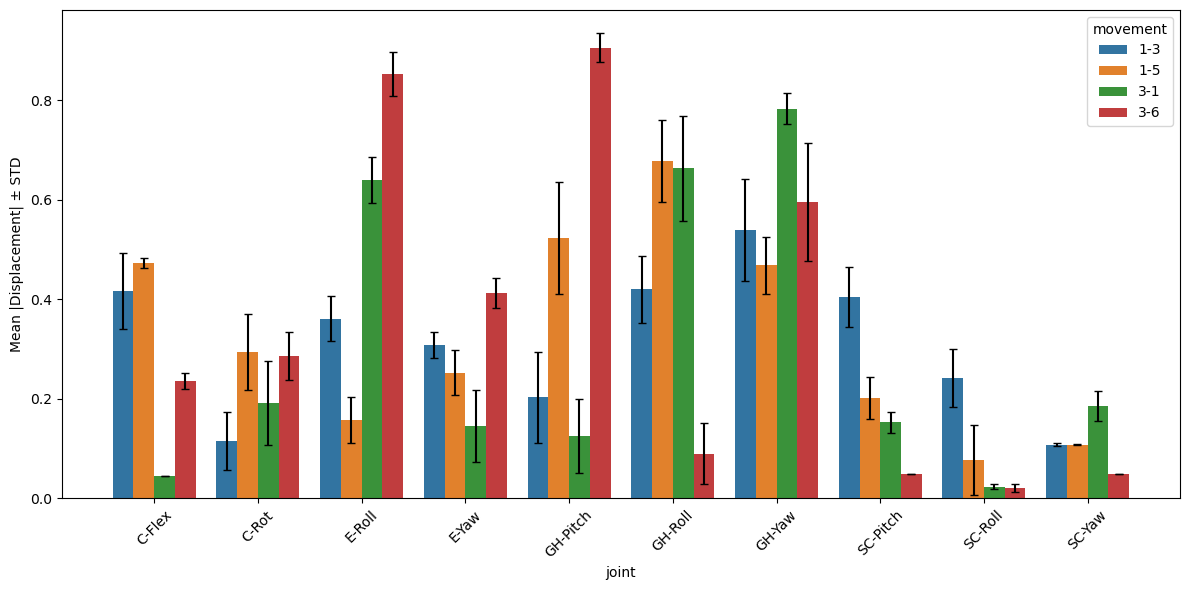

In [37]:
joint_order = [
    "columna_rot_joint",
    "columna_flex_joint",
    "sternoclavicular_yaw_joint",
    "sternoclavicular_pitch_joint",
    "sternoclavicular_roll_joint",
    "glenohumeral_yaw_joint",
    "glenohumeral_pitch_joint",
    "glenohumeral_roll_joint",
    "elbow_yaw_joint",
    "elbow_roll_joint",
]

movements = ["1-3", "1-5", "3-6", "3-1"]

rows = []

for _, row in df[df["converged"]].iterrows():

    if row["movement"] not in movements:
        continue

    for j in joint_order:
        rows.append({
            "movement": row["movement"],
            "joint": j,
            "disp": abs(row[f"{j}_disp"])
        })

long_df = pd.DataFrame(rows)

stats = long_df.groupby(["movement", "joint"]).agg(
    mean=("disp", "mean"),
    std=("disp", "std")
).reset_index()

joint_labels = {
    "columna_rot_joint": "C-Rot",
    "columna_flex_joint": "C-Flex",
    "sternoclavicular_yaw_joint": "SC-Yaw",
    "sternoclavicular_pitch_joint": "SC-Pitch",
    "sternoclavicular_roll_joint": "SC-Roll",
    "glenohumeral_yaw_joint": "GH-Yaw",
    "glenohumeral_pitch_joint": "GH-Pitch",
    "glenohumeral_roll_joint": "GH-Roll",
    "elbow_yaw_joint": "E-Yaw",
    "elbow_roll_joint": "E-Roll",
}

stats["joint"] = stats["joint"].map(joint_labels)

plt.figure(figsize=(12,6))
ax = plt.gca()

stats["joint"] = pd.Categorical(
    stats["joint"],
    categories=stats["joint"].unique(),
    ordered=True
)

sns.barplot(
    data=stats,
    x="joint",
    y="mean",
    hue="movement",
    errorbar=None,
    ax=ax
)

for patch, (_, row) in zip(ax.patches, stats.iterrows()):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()

    ax.errorbar(
        x=x,
        y=y,
        yerr=row["std"],
        fmt="none",
        ecolor="black",
        capsize=3
    )

plt.xticks(rotation=45)
plt.ylabel("Mean |Displacement| ± STD")
plt.tight_layout()
plt.show()

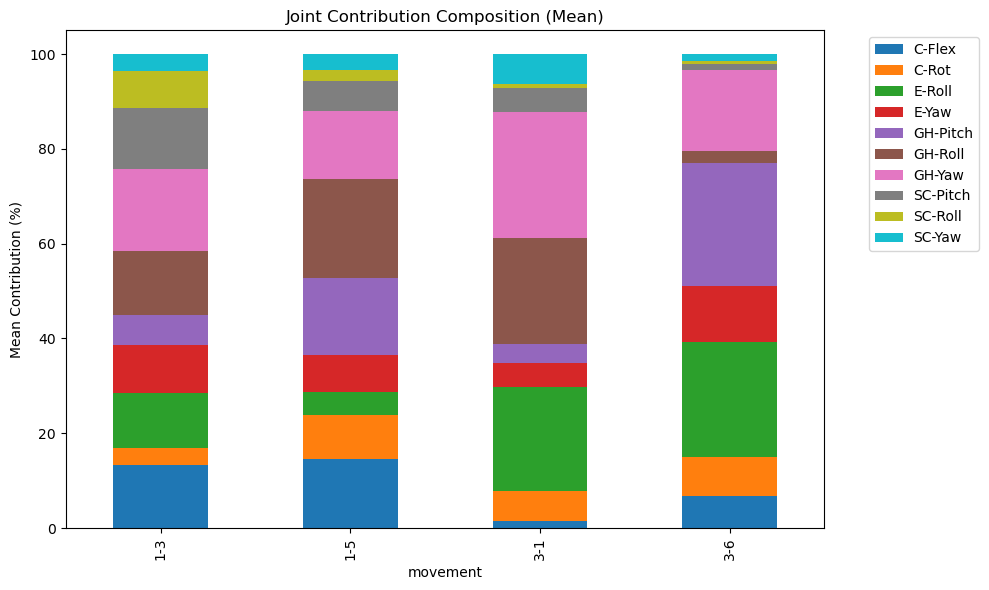

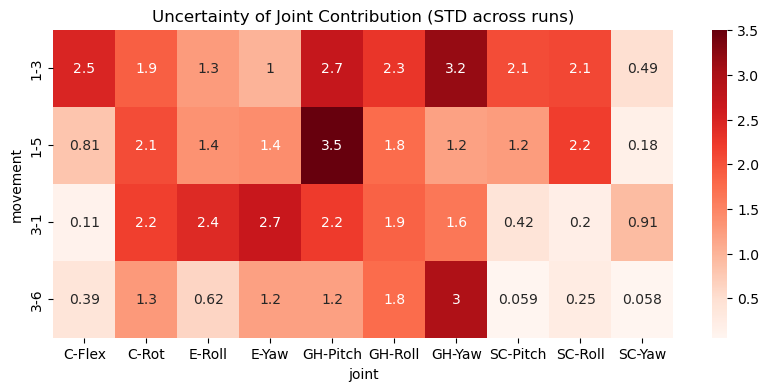

In [42]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):

        rows.append({
            "movement": row["movement"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

stats = long_df.groupby(["movement", "joint"]).agg(
    mean=("contribution", "mean"),
    std=("contribution", "std")
).reset_index()

stats["joint"] = stats["joint"].map(joint_labels)

pivot = stats.pivot(
    index="movement",
    columns="joint",
    values="mean"
)

ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("Mean Contribution (%)")
plt.title("Joint Contribution Composition (Mean)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
err = stats.pivot(
    index="movement",
    columns="joint",
    values="std"
)

plt.figure(figsize=(10,4))

sns.heatmap(
    err,
    annot=True,
    cmap="Reds"
)

plt.title("Uncertainty of Joint Contribution (STD across runs)")
plt.show()

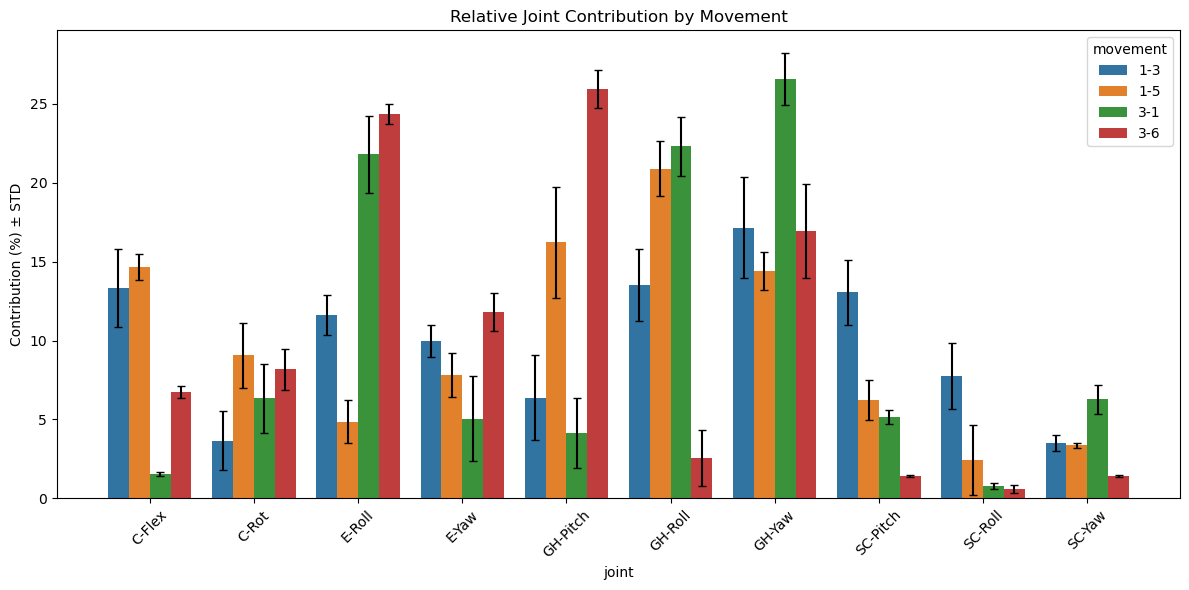

In [43]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):

        rows.append({
            "movement": row["movement"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

stats = long_df.groupby(["movement", "joint"]).agg(
    mean=("contribution", "mean"),
    std=("contribution", "std")
).reset_index()

stats["joint"] = stats["joint"].map(joint_labels)


plt.figure(figsize=(12,6))
ax = plt.gca()

sns.barplot(
    data=stats,
    x="joint",
    y="mean",
    hue="movement",
    errorbar=None,
    ax=ax
)

for patch, (_, row) in zip(ax.patches, stats.iterrows()):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()

    ax.errorbar(
        x=x,
        y=y,
        yerr=row["std"],
        fmt="none",
        ecolor="black",
        capsize=3
    )

plt.xticks(rotation=45)
plt.ylabel("Contribution (%) ± STD")
plt.title("Relative Joint Contribution by Movement")
plt.tight_layout()
plt.show()

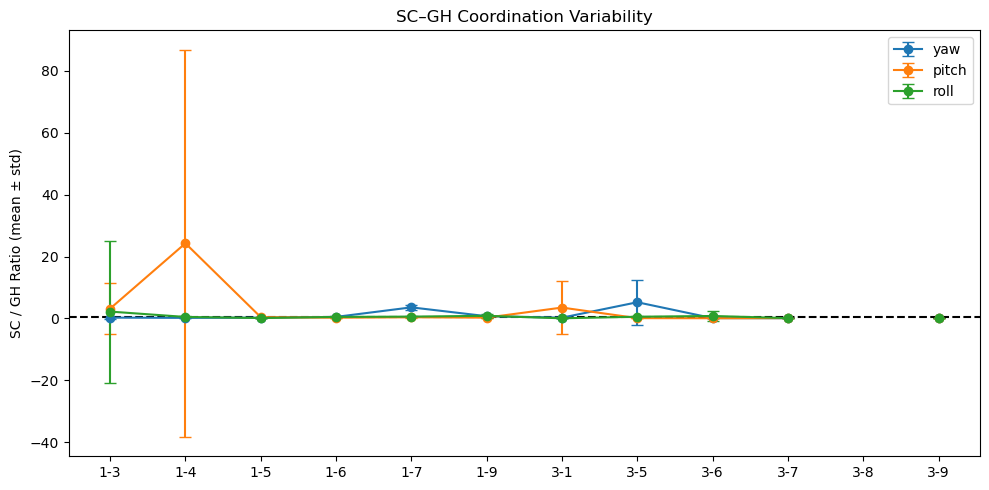

   movement   axis       mean        std
0       1-3    yaw   0.254092   0.317746
1       1-3  pitch   3.154013   8.232890
2       1-3   roll   2.206423  22.966254
3       1-4    yaw   0.173586   0.009595
4       1-4  pitch  24.274581  62.582849
5       1-4   roll   0.472323   0.143955
6       1-5    yaw   0.234782   0.030367
7       1-5  pitch   0.413123   0.177394
8       1-5   roll   0.119507   0.109222
9       1-6    yaw   0.486907   0.142670
10      1-6  pitch   0.228634   0.068940
11      1-6   roll   0.476066   0.205226
12      1-7    yaw   3.569806   0.738937
13      1-7  pitch   0.365127   0.112138
14      1-7   roll   0.577327   0.067544
15      1-9    yaw   0.712224   0.168346
16      1-9  pitch   0.248343   0.173730
17      1-9   roll   0.834544   0.632327
18      3-1    yaw   0.237569   0.039745
19      3-1  pitch   3.502152   8.623167
20      3-1   roll   0.036677   0.010713
21      3-5    yaw   5.222271   7.338264
22      3-5  pitch   0.084533   0.005509
23      3-5   ro

In [ ]:
sc_gh_pairs = [
    ("yaw",   "sternoclavicular_yaw_joint",   "glenohumeral_yaw_joint"),
    ("pitch", "sternoclavicular_pitch_joint", "glenohumeral_pitch_joint"),
    ("roll",  "sternoclavicular_roll_joint",  "glenohumeral_roll_joint"),
]

rows = []

for movement in sorted(df["movement"].unique()):

    subset = df[
        (df["movement"] == movement) &
        (df["converged"])
    ]

    for axis, sc, gh in sc_gh_pairs:

        sc_vals = subset[f"{sc}_disp"].abs()
        gh_vals = subset[f"{gh}_disp"].abs()

        ratio = sc_vals / gh_vals.replace(0, np.nan)
        #ratio = np.log((sc_vals + 1e-8) / (gh_vals + 1e-8))

        rows.append({
            "movement": movement,
            "axis": axis,
            "mean": ratio.mean(),
            "std": ratio.std()
        })

stats_df = pd.DataFrame(rows)

plt.figure(figsize=(10,5))

for axis in stats_df["axis"].unique():

    sub = stats_df[stats_df["axis"] == axis]

    # plt.errorbar(
    #     sub["movement"],
    #     sub["mean"],
    #     yerr=sub["std"],
    #     label=axis,
    #     capsize=4,
    #     marker="o"
    # )

plt.axhline(0.5, linestyle="--", color="black")

plt.ylabel("SC / GH Ratio (mean ± std)")
plt.title("SC–GH Coordination Variability")

#plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

print(stats_df)